# TFIM sin Ruido

Para la simulación realizada, se escogí fronteras periódicas (importante porque si cambia eso cambia algunas partes del código, aunque nada letal).

Procuré inventir un buen tiempo en comentarlo, modificarlo y optimizarlo para que no sea solo un chorro de código y teoría sin contexto, y ojalá facilite todo lo demás como investigar a fondo para el informe técnico. Intenté explicar aunque sea por encima lo que usé, y usé muchas secciones, así si tenemos que cambiar algo está más aislado

Las secciones que dicen **WIP** son a las que enserio les falta desarrollo


Obvio mucho de esto es como se me ocurrió hacerlo, pero cambienlo a placer

### Descarga de requirements.txt

Útil, en cualquier momento se puede generar el .txt con !pip freeze > requirements.txt, aunque por alguna razón igual algunos se quedaban fuera, no estoy seguro porqué

In [ ]:
!pip install pytket
!pip install Guppy
!pip install guppylang

  Using cached guppy-0.1.11.tar.gz (500 kB)
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [ ]:
!pip install -r requirements.txt

  Using cached anyio-4.11.0-py3-none-any.whl.metadata (4.1 kB)
  Using cached appdirs-1.4.4-py2.py3-none-any.whl.metadata (9.0 kB)
  Using cached asttokens-2.4.1-py2.py3-none-any.whl.metadata (5.2 kB)
  Using cached async_lru-2.0.5-py3-none-any.whl.metadata (4.5 kB)
  Using cached attrs-25.4.0-py3-none-any.whl.metadata (10 kB)
  Using cached babel-2.17.0-py3-none-any.whl.metadata (2.0 kB)
  Using cached beautifulsoup4-4.14.2-py3-none-any.whl.metadata (3.8 kB)
  Using cached bleach-6.2.0-py3-none-any.whl.metadata (30 kB)
  Using cached certifi-2025.10.5-py3-none-any.whl.metadata (2.5 kB)
  Using cached cffi-2.0.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (2.6 kB)
  Using cached charset_normalizer-3.4.4-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (37 kB)
  Using cached chromium-0.0.0-py3-none-any.whl.metadata (615 bytes)
  Using cached cirq-1.6.1-py3-none-any.whl.metadata (16 kB)
  Using cached cirq_aqt-1.6.1-py3-non

## Librerías e inicializaciones importantes

In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import scipy.sparse as sp
from scipy.sparse import csr_matrix #matrices más eficientes (mejora escalabilidad)
from scipy.sparse.linalg import eigsh, expm_multiply #Útil para la evolución temporal con ED
from functools import reduce
from scipy.optimize import minimize
from pytket.circuit import Circuit

Con el campo transversal inicial para el barrido adiabatico (fase profundamente paramagnetica). Se escoge estrictamente por encima de cualquier valor de h que barramos (incluyendo 2.0) para que el $\frac{\Delta h}{\Delta t}$ nunca colapse a ~0 pasos.

In [ ]:
H_INIT = 3.0

Finalmente, por facilidad se trabaja la decisión de realizar una simulación en hardware real con Nexus o solo realizar una simulación local clásica mediante un Boolean

In [ ]:
RUN_ON_NEXUS = False

## 1. Diagonalización Exacta

### Construcción de operadores de Pauli
Retorna la matriz dispersa (csr) $2^N \times 2^N$ de Pauli actuando en el qubit n.
    Se utiliza scipy.sparse.kron para evitar generar la matriz densa en memoria,
    mejorando la escalabilidad. Se definen dos funciones similares, la básica para N's pequeños, y se usa un método de matrices dispersas para valores elevados de N

In [ ]:
def get_pauli(n, size, pauli_type):
    """Retorna la matriz densa 2^size x 2^size de Pauli actuando en el qubit n.
    (Version densa: se mantiene para ED en N pequeno, p.ej. N=6/N=8, donde
    es simple y ya esta validada. Para N grande usar get_pauli_sparse.)"""
    if pauli_type not in ['x', 'y', 'z']:
        raise ValueError("pauli_type must be 'x', 'y', or 'z'")
    pauli_matrices = {
        'x': np.array([[0, 1], [1, 0]], dtype=complex),
        'y': np.array([[0, -1j], [1j, 0]], dtype=complex),
        'z': np.array([[1, 0], [0, -1]], dtype=complex)
    }
    op = pauli_matrices[pauli_type]
    full_op = 1
    for i in range(size):
        full_op = np.kron(full_op, op if i == n else np.eye(2))
    return full_op

def get_pauli_sparse(n, size, pauli_type):
    """
    Retorna la matriz dispersa (csr) 2^N x 2^N de Pauli actuando en el qubit n.
    Se utiliza scipy.sparse.kron para evitar generar la matriz densa en memoria,
    mejorando la escalabilidad.
    """
    pauli_matrices = {
        'x': sp.csr_matrix([[0, 1], [1, 0]], dtype=float),
        'y': sp.csr_matrix([[0, -1j], [1j, 0]], dtype=complex),
        'z': sp.csr_matrix([[1, 0], [0, -1]], dtype=float)
    }
    eye_2 = sp.eye(2, format='csr')
    op = pauli_matrices[pauli_type]
    ops = [eye_2] * size
    ops[n] = op
    full_op = ops[0]
    for i in range(1, size):
        full_op = sp.kron(full_op, ops[i], format='csr')
    return full_op


### Hamiltoniano del Modelo TFIM con frontera periódica

Construye el Hamiltoniano $H = -J \sum ZZ - h \sum X$ (frontera periódica). Similarmente se definen 2 métodos, uno para N pequeño y otro para N grande
    Retorna directamente una matriz dispersa csr

In [ ]:
def build_tfim_hamiltonian(N, J=1.0, h=1.0):
    """Construye H = -J sum ZZ - h sum X (frontera periodica). Version
    densa (via get_pauli), usada para N pequeno (N=6/N=8)."""
    H = csr_matrix((2**N, 2**N), dtype=complex)
    for i in range(N):
        j = (i + 1) % N
        H -= J * (get_pauli(i, N, 'z') @ get_pauli(j, N, 'z'))
    for i in range(N):
        H -= h * get_pauli(i, N, 'x')
    return H.real

def build_tfim_hamiltonian_sparse(N, J=1.0, h=1.0):
    """
    Construye el Hamiltoniano H = -J sum ZZ - h sum X (frontera periodica).
    Retorna directamente una matriz dispersa csr -- factible hasta 20.
    """
    dim = 2**N
    H = sp.csr_matrix((dim, dim), dtype=float)
    for i in range(N):
        j = (i + 1) % N
        Zi = get_pauli_sparse(i, N, 'z')
        Zj = get_pauli_sparse(j, N, 'z')
        H -= J * (Zi @ Zj)
    for i in range(N):
        sx_i = get_pauli_sparse(i, N, 'x')
        H -= h * sx_i
    return H

### Cálculo de Diagonalización Exacta (ED) con observables
Calcula los valores esperados del estado fundamental exacto del TFIM
    mediante diagonalización dispersa (eigsh). Los operadores observables
    se construyen una sola vez y se reutilizan para todos los h

In [ ]:
def ed_baseline(N=6, h_values=[0.5, 1.0, 2.0]):

    results = []
    print("\n" + "=" * 82)
    print(f"LINEA BASE DE DIAGONALIZACION EXACTA (N={N})")
    print("=" * 82)
    print(f"{'h/J':^8} | {'<Z>':^12} | {'<X>':^12} | {'<Zi Zi+1>':^14} | {'E/N':^12}")
    print("-" * 82)

    dim = 2**N
    Mz_op = np.zeros((dim, dim), dtype=complex)
    Mx_op = np.zeros((dim, dim), dtype=complex)
    Mzz_op = np.zeros((dim, dim), dtype=complex)
    for i in range(N):
        j = (i + 1) % N  # condicion periodica
        Zi, Zj, Xi = get_pauli(i, N, 'z'), get_pauli(j, N, 'z'), get_pauli(i, N, 'x')
        Mz_op += Zi; Mx_op += Xi; Mzz_op += Zi @ Zj
    Mz_sq_op = Mz_op @ Mz_op  # pre-calculado, se reutiliza para todo h

    for h in h_values:
        H = build_tfim_hamiltonian(N, J=1.0, h=h)
        # 'SA' = Smallest Algebraic: el estado base
        eigvals, eigvecs = eigsh(H, k=1, which='SA')
        gs = eigvecs[:, 0]

        mz_sq = (gs.conj().T @ (Mz_sq_op @ gs)).real.item()
        mz_rms = np.sqrt(max(mz_sq, 0.0)) / N
        mx = (gs.conj().T @ (Mx_op @ gs)).real.item() / N
        mzz = (gs.conj().T @ (Mzz_op @ gs)).real.item() / N
        energy = eigvals[0].real / N

        results.append({'h': h, 'mz_rms': mz_rms, 'mx': mx, 'mzz': mzz, 'energy': energy})
        print(f"{h:^8.1f} | {mz_rms:^12.6f} | {mx:^12.6f} | {mzz:^14.6f} | {energy:^12.6f}")
    print("=" * 82 + "\n")
    return results

### Evolución Temporal mediante Aproximación de Taylor

Simula la dinámica continua del sistema a lo largo del tiempo partiendo de un estado inicial conocido, sin incurrir en los costos de memoria de la diagonalización completa, pero aun así calificando como un método de Diagonalización Exacta.

In [ ]:
def time_evolution_example(N, t_end=1.0):
    print(f"Demostración de Evolución Temporal para N={N} hasta t={t_end}...")
    H = build_tfim_hamiltonian(N, J=1.0, h=1.0)

    # Estado inicial: Todos los spines hacia arriba en Z |00...0>
    dim = 2**N
    psi_0 = np.zeros(dim, dtype=complex)
    psi_0[0] = 1.0

    # Aplicar la evolución |psi(t)> = exp(-iHt) |psi(0)>
    # expm_multiply requiere que la matriz y el tiempo estén en un mismo operador
    operator = -1j * t_end * H

    start_t = time.time()
    psi_t = expm_multiply(operator, psi_0)
    end_t = time.time()

    print(f"Evolución completada en {end_t - start_t:.4f} segundos.")
    print(f"Norma del vector resultante: {np.linalg.norm(psi_t):.6f} (Debe ser ~1.0)\n")
    return psi_t

## 2. Generación del circuito Adiabático en 1D

Traduce el problema de la evolución de tiempo continuo dado por el exponencial $e^{-iHt}$ y lo separa en bloques discretos ejecutables en un computador cuántico, lo cual es necesario dado que el hardware cuántico no puede computar el exponencial directo, pero sí puede computar compuertas.

### Coloreo de bordes
Este paso es realizado con tal de que ningún borde adjacente comparta color, lo cual requiere entre 2 a 3 colores según la paridad del número de qubits. El propósito es que para el término de interacción en una capa de Trotter:
$$
U_{zz} = e^{-i\theta\sum_{<i,j>}Z_i Z_j}
$$
Esto puede ser escrito en terminos de una productoria.
$$
U_{zz}= \prod_{ejes (i,j)} e^{-i\theta Z_i Z_j}
$$

A esto se le deben aplica una compuerta Rzz, la cual se rige bajo la relación $[Z_i Z_j, Z_i Z_k]\neq 0$      $\forall i\neq j$

Es decir, no conmuta cuando se comparte un qubit en la expresión, por lo tanto no se pueden aplicar las compuertas a la misma vez. Sin embargo, si no hay qubits compartidos, existe conmutación, por lo que se puede aplicar la compuerta en paralelo.

Entonces, se colorean los bordes tal que se obtienen grupos de qubits en diferentes colores. A cada grupo se le aplican las compuertas en paralelo, aumentando notablemente la eficiencia del algoritmo, específicamente la profundidad de circuitos.

In [ ]:
def edge_coloring(graph):
    """Se colorean los bordes tal que no hay colores repetidos en bordes adyacentes"""
    line_graph = nx.line_graph(graph)
    edge_colors = nx.coloring.greedy_color(line_graph)
    color_groups = {}
    for edge, color in edge_colors.items():
        color_groups.setdefault(color, []).append(edge)
    return list(color_groups.values())

def build_single_layer_circuit(N, color_edges, theta_x, theta_zz, mirror=True):
    """Una capa de trotter (X/2 - ZZ - X/2) como un circuit pequeño y de tamaño constante"""
    layer = QuantumCircuit(N)
    for i in range(N):
        layer.rx(theta_x / 2 if mirror else theta_x, i)
    for edge_list in color_edges:
        for edge in edge_list:
            layer.rzz(theta_zz, edge[0], edge[1])
    for i in range(N):
        layer.rx(theta_x / 2 if mirror else theta_x, i)
    return layer


## Circuitos sustituto de PyTKET y motor rápido local

Se utiliza un motor rápido de propagación mediante arreglos de NumPy. Mientras que esta implementación podría ser hecha exclusivamente con PyTKET, la cuál realiza el circuito cada iteración de Trotter, pero esto aumenta notablemente el costo total al tener que reconstruir el circuito entero, y esto causa que el modelo no sea escalable para N elevado. Por lo tanto, se utiliza Numpy específicamente para el estudio de escalamiento, donde es necesario, y luego se utiliza PyTKET para todos los demás resultados (Notar como es pedido evaluar para N = 6 y N = 8, donde no se da el problema de escalamiento para PyTKET)

### Compuertas

In [ ]:
def apply_rx_inplace(vec, qubit, theta_rad, N):
    """Rx(theta) = exp(-i*theta*X/2), theta en RADIANES."""
    c, s = np.cos(theta_rad / 2), -1j * np.sin(theta_rad / 2)
    mask = 1 << (N - 1 - qubit)
    idx = np.arange(len(vec))
    idx0 = idx[(idx & mask) == 0]
    idx1 = idx0 | mask
    v0, v1 = vec[idx0].copy(), vec[idx1].copy()
    vec[idx0] = c * v0 + s * v1
    vec[idx1] = s * v0 + c * v1

def apply_zzphase_inplace(vec, q1, q2, theta_rad, N):
    """ZZPhase(theta) = exp(-i*theta*Z1Z2/2), theta en RADIANES. Es
    diagonal, entonces es solo una multiplicacion elemento a elemento."""
    idx = np.arange(len(vec))
    b1 = (idx >> (N - 1 - q1)) & 1
    b2 = (idx >> (N - 1 - q2)) & 1
    same = (b1 == b2)
    phase = np.where(same, np.exp(-1j * theta_rad / 2), np.exp(1j * theta_rad / 2))
    vec *= phase

### Inicialización de estados

In [ ]:
def init_plus_state(N):
    """|+++...+>, el estado base de H = -sum X."""
    return np.full(2**N, 1.0 / np.sqrt(2**N), dtype=complex)

def init_computational_state(label, N):
    """Estado producto de la base computacional a partir de un bitstring."""
    idx = int(label, 2) if isinstance(label, str) else 0
    vec = np.zeros(2**N, dtype=complex)
    vec[idx] = 1.0
    return vec

### Capa de PyTKET
Estas son las funciones asociadas al funcionamiento de la capa. Por más que se usará Numpy para el escalamiento, esta es la capa destinada a ser enviada para una simulación de H2 en Nexus

In [ ]:
def build_pytket_layer(N, color_edges, theta_x, theta_zz, mirror=True, prefix_h=False):
    """El circuito de pytket CANONICO y enviable a Nexus/H2 para una capa
    de Trotter (X/2 - ZZ - X/2). Los angulos se convierten de radianes a
    medias-vueltas (/pi) porque esa es la convencion de pyTKET."""
    circ = Circuit(N)
    if prefix_h:
        for i in range(N):
            circ.H(i)
    ax = (theta_x / 2 if mirror else theta_x) / np.pi
    az = theta_zz / np.pi
    for i in range(N):
        circ.Rx(ax, i)
    for edge_list in color_edges:
        for (i, j) in edge_list:
            circ.ZZPhase(az, i, j)
    for i in range(N):
        circ.Rx(ax, i)
    return circ

def apply_layer_fast(vec, N, color_edges, theta_x, theta_zz, mirror=True):
    """Aplica la MISMA capa que build_pytket_layer directo sobre un
    vector de estado, en radianes (la conversion /pi solo importa al
    construir el objeto Circuit de pytket)."""
    tx = theta_x / 2 if mirror else theta_x
    for i in range(N):
        apply_rx_inplace(vec, i, tx, N)
    for edge_list in color_edges:
        for (i, j) in edge_list:
            apply_zzphase_inplace(vec, i, j, theta_zz, N)
    for i in range(N):
        apply_rx_inplace(vec, i, tx, N)

### Verificación

Es bueno hacer "sanity checks" cuando se tiene un método que busca imitar otro

In [ ]:
def _validar_motor_vs_pytket(N=4, seed=0):
    """Chequeo de cordura: el motor rapido debe coincidir EXACTAMENTE con
    el propio simulador de pytket. Se corre una vez al importar el modulo."""
    rng = np.random.default_rng(seed)
    graph = nx.path_graph(N); graph.add_edge(N - 1, 0)
    ce = edge_coloring(graph)
    theta_x, theta_zz = rng.uniform(-1, 1), rng.uniform(-1, 1)

    vec = init_plus_state(N)
    apply_layer_fast(vec, N, ce, theta_x, theta_zz, mirror=True)

    circ = build_pytket_layer(N, ce, theta_x, theta_zz, mirror=True, prefix_h=True)
    sv = np.array(circ.get_statevector())
    assert np.allclose(vec, sv, atol=1e-9), "El motor rapido no coincide con pytket!"
    return True

_validar_motor_vs_pytket()
print("Motor de propagacion rapida validado contra pytket.Circuit.get_statevector(). Se determina que es fidedigno")

Motor de propagacion rapida validado contra pytket.Circuit.get_statevector(). Se determina que es fidedigno


## 3. Propagación del vector estado: Adiabático

Realiza Computación Cuántica Adiabática (AQC). Se construye sobre el teorema adiabático, que dicta que si un Hamiltoniano cambia infinitamente lento y el estado inicial es un eigenestado no degenerado, el sistema permanecerá en el autoestado instantáneo correspondiente durante toda su evolución. Se relaciona mucho con el Quantum Annealing, por más que se aclara que no es en sí Quantum Annealing.

En términos prácticos, este modelo de solución toma un Hamiltoniano complejo cuyo estado base describe la solución del problema de interés. Se escoge un Hamiltoniano sencillo y se prepara con este estado base. Paulatinamente, se evoluciona el Hamiltoniano sencillo hacia el complejo. Por el teorema adiabático, la solución del sistema evolucionado es la solución del problema. Puesto que a veces se usará el modelo con escalabilidad (Numpy) o el de hardware real (PyTKET), se tienen 2 funciones

In [ ]:
def run_adiabatic_exact(N, steps, h_target, J_target, dt, mirror=True, h_init=H_INIT):
    """Propaga la evolucion de Trotter adiabatica paso a paso (motor
    rapido, equivalente a pytket) y produce los valores de los
    observables. Sin ruido de muestreo (shots): son valores exactos."""
    graph = nx.path_graph(N); graph.add_edge(N - 1, 0)
    color_edges = edge_coloring(graph)
    edges = [(i, (i + 1) % N) for i in range(N)]
    mz_tab, mzz_tab = precompute_observable_tables(N, edges)

    vec = init_plus_state(N)
    z_expect, mzz, x_expect = np.zeros(steps), np.zeros(steps), np.zeros(steps)

    for step in range(1, steps + 1):
        s = step / steps
        h_eff = (1 - s) * h_init + s * h_target
        J_eff = s * J_target
        theta_x = -2 * h_eff * dt
        theta_zz = -2 * J_eff * dt
        apply_layer_fast(vec, N, color_edges, theta_x, theta_zz, mirror=mirror)
        z_expect[step - 1], mzz[step - 1], x_expect[step - 1] = fast_observables(vec, N, mz_tab, mzz_tab)

    return z_expect, mzz, x_expect

def run_adiabatic_nexus(N, steps, h_target, J_target, dt, mirror=True,
                        h_init=H_INIT, n_shots=1000, max_points=15):
    """
    Versión para Nexus del barrido adiabático.
    Envía el circuito a Nexus cada cierto número de pasos.
    """
    graph = nx.path_graph(N); graph.add_edge(N - 1, 0)
    color_edges = edge_coloring(graph)
    edges = [(i, (i + 1) % N) for i in range(N)]
    mz_tab, mzz_tab = precompute_observable_tables(N, edges)

    # Estado inicial |+++...+>
    circ = Circuit(N)
    for i in range(N):
        circ.H(i)

    if steps <= max_points:
        sample_steps = list(range(1, steps + 1))
    else:
        sample_steps = list(np.linspace(1, steps, max_points, dtype=int))

    z_samples, mzz_samples, x_samples, times_samples = [], [], [], []
    current_step = 0

    for target_step in sample_steps:
        while current_step < target_step:
            current_step += 1
            s = current_step / steps
            h_eff = (1 - s) * h_init + s * h_target
            J_eff = s * J_target

            theta_x = -2 * h_eff * dt
            theta_zz = -2 * J_eff * dt
            ax = (theta_x / 2 if mirror else theta_x) / np.pi
            az = theta_zz / np.pi

            for i in range(N):
                circ.Rx(ax, i)
            for edge_list in color_edges:
                for (i, j) in edge_list:
                    circ.ZZPhase(az, i, j)
            for i in range(N):
                circ.Rx(ax, i)

        # Medir en Z
        print(f"  [Nexus] Enviando adiabático paso {target_step}/{steps} para h={h_target}...")
        res = submit_to_nexus(circ, n_shots=n_shots,
                              job_name=f"adiab-N{N}-h{int(h_target*10)}-step{target_step}")
        counts = res.get_counts()
        mz_sq_sum, mzz_sum, total = 0.0, 0.0, 0
        for bit_tuple, count in counts.items():
            spins = [1 - 2 * b for b in bit_tuple]
            mz = sum(spins) / N
            mz_sq_sum += (mz ** 2) * count
            zz = sum(spins[i] * spins[(i+1)%N] for i in range(N)) / N
            mzz_sum += zz * count
            total += count
        z_samples.append(np.sqrt(mz_sq_sum / max(total, 1)))
        mzz_samples.append(mzz_sum / max(total, 1))

        # Medir en X
        circ_x = circ.copy()
        for i in range(N):
            circ_x.H(i)
        res_x = submit_to_nexus(circ_x, n_shots=n_shots,
                                job_name=f"adiab-X-N{N}-h{int(h_target*10)}-step{target_step}")
        counts_x = res_x.get_counts()
        mx_sum, total_x = 0.0, 0
        for bit_tuple, count in counts_x.items():
            spins = [1 - 2 * b for b in bit_tuple]
            mx_sum += (sum(spins) / N) * count
            total_x += count
        x_samples.append(mx_sum / max(total_x, 1))
        times_samples.append(target_step * dt)

    times_full = np.arange(1, steps + 1) * dt
    z_expect = np.interp(times_full, times_samples, z_samples)
    mzz = np.interp(times_full, times_samples, mzz_samples)
    x_expect = np.interp(times_full, times_samples, x_samples)

    return z_expect, mzz, x_expect

## 4. Evolución temporal del Hamiltoniano fijo desde un estado producto

Conceptualmente, es el opuesto de la anterior sección. En ugar de analizar un sistema bajo un cambio sumamente suave y lento, este es el análisis de un sistema después de un choque brusco, llamado "quench". Aquí, se implementa el Hamiltoniano físico en un sistema completamente congelado.

A su vez, se realiza una comparativa entre la Diagonalización Exacta y la Trotterización de segundo orden. Al ser esta un simulación ideal, sin ruido, el error obtenido es el error de Trotter.

### Evolución temporal con ED
Computa la evolución temporal con ED a partir de un estado producto, según la etiqueta en bitstring

In [ ]:
def ed_time_evolution_exact(N, h, J, dt, steps, initial_state_label=None):
    if initial_state_label is None:
        initial_state_label = '0' * N
    H = build_tfim_hamiltonian(N, J=1.0, h=h).A
    evals, evecs = np.linalg.eigh(H)
    idx = int(initial_state_label, 2) if isinstance(initial_state_label, str) else 0
    psi0 = np.zeros(2**N, dtype=complex); psi0[idx] = 1.0
    c0 = evecs.conj().T @ psi0  # psi0 expresado en la base de energia

    Z_ops = [get_pauli(i, N, 'z') for i in range(N)]
    X_ops = [get_pauli(i, N, 'x') for i in range(N)]
    Mz_sq_op = sum(Z_ops) @ sum(Z_ops)
    Mx_op = sum(X_ops)
    Mzz_op = sum(Z_ops[i] @ Z_ops[(i + 1) % N] for i in range(N))

    times = np.arange(1, steps + 1) * dt
    z_rms, mzz, x_exp = np.zeros(steps), np.zeros(steps), np.zeros(steps)
    for t_idx, t in enumerate(times):
        psi_t = evecs @ (np.exp(-1j * evals * t) * c0)
        mz_sq = np.real(psi_t.conj() @ (Mz_sq_op @ psi_t))
        z_rms[t_idx] = np.sqrt(max(mz_sq, 0.0)) / N
        mzz[t_idx] = np.real(psi_t.conj() @ (Mzz_op @ psi_t)) / N
        x_exp[t_idx] = np.real(psi_t.conj() @ (Mx_op @ psi_t)) / N
    return times, z_rms, mzz, x_exp

### Trotter para el Hamiltoniano fijo

Evolución de Trotter bajo un Hamiltoniano fijo a partir de un estado producto

In [ ]:
def run_trotter_fixed_hamiltonian(N, h, J, dt, steps, initial_state_label=None, mirror=True):
    if initial_state_label is None:
        initial_state_label = '0' * N

    graph = nx.path_graph(N)
    graph.add_edge(N - 1, 0)
    color_edges = edge_coloring(graph)

    Z_ops = [get_pauli(i, N, 'z') for i in range(N)]
    X_ops = [get_pauli(i, N, 'x') for i in range(N)]
    Mz_op = sum(Z_ops)
    Mz_sq_op = Mz_op @ Mz_op
    Mx_op = sum(X_ops)
    Mzz_op = sum(Z_ops[i] @ Z_ops[(i + 1) % N] for i in range(N))

    state = Statevector.from_label(initial_state_label)

    theta_x = -2 * h * dt
    theta_zz = -2 * J * dt

    z_rms = np.zeros(steps)
    mzz = np.zeros(steps)
    x_exp = np.zeros(steps)

    for step in range(1, steps + 1):
        layer = build_single_layer_circuit(N, color_edges, theta_x, theta_zz, mirror=mirror)
        state = state.evolve(layer)

        vec = state.data
        mz_sq = np.real(vec.conj() @ (Mz_sq_op @ vec))
        z_rms[step - 1] = np.sqrt(max(mz_sq, 0.0)) / N
        mzz[step - 1] = np.real(vec.conj() @ (Mzz_op @ vec)) / N
        x_exp[step - 1] = np.real(vec.conj() @ (Mx_op @ vec)) / N

    times = np.arange(1, steps + 1) * dt
    return times, z_rms, mzz, x_exp

## N-Escalamiento

Debido a buscar simular hasta el rango de 4-20 espines, la dimensión de la matriz se puede volver difícil de manejar para un computador ordinario. Incluso manejando matrices dispersas mediante Python, las matrices csr no logran comprimir lo suficiente el problema para resolverlo con comodidad.

La solución a esto es buscar algún método para realizar Trotter libre de matrices. Para esto, en lugar de operar directo sobre las matrices, se precalculan el valor de magnetización y correlación que correspondería a un "bitstring" clásico y se guardan en un array unidimensional.

Luego, durante la simulación, solo es necesario multiplicar los pesos de probabilidad absolutos del vector estado cuántico directamente sobre el arreglo pre-calculo, tal que se puedan extraer los observables.

### Precomputación de los observables
Se precomputan los eigenvalores diagonales de  M_z = sum Z_i y M_zz = sum_edges Z_i Z_j para cada estado en la base computacional.

In [ ]:
def precompute_observable_tables(N, edges):
    """Se precomputan los eigenvalores diagonales de M_z = sum Z_i y
    M_zz = sum_edges Z_i Z_j para cada estado en la base computacional.
    (Convencion big-endian de pytket: qubit i -> posicion de bit N-1-i.)"""
    idx = np.arange(2**N, dtype=np.int64)
    bit_pos = N - 1 - np.arange(N)
    bits = ((idx[:, None] >> bit_pos[None, :]) & 1).astype(np.int8)
    z = 1 - 2 * bits  # bit=0 -> autovalor Z +1 ; bit=1 -> -1
    mz_per_state = z.sum(axis=1).astype(np.float64)
    mzz_per_state = np.zeros(2**N, dtype=np.float64)
    for (i, j) in edges:
        mzz_per_state += z[:, i] * z[:, j]
    return mz_per_state, mzz_per_state

### Cálculo de observables por precomputación
Calcula de manera exacta $\langle Z\rangle, \langle Z_i Z_{i+1}\rangle$ directo de las amplitudes del vector estado

In [ ]:
def fast_observables(vec, N, mz_per_state, mzz_per_state):
    probs = np.abs(vec) ** 2
    z_rms = np.sqrt(np.sum(probs * mz_per_state ** 2)) / N
    zz = np.sum(probs * mzz_per_state) / N
    idx = np.arange(len(vec))
    x_sum = 0.0
    for i in range(N):
        flipped = idx ^ (1 << (N - 1 - i))
        x_sum += np.real(np.sum(np.conj(vec) * vec[flipped]))
    return z_rms, zz, x_sum / N


### Trotter con quench
Funcionalmente, es igual a Trotter para el Hamiltoniano fijo, pero sustituyendo la medición basada en matrices por la rutina del cálculo de observables por precomputación. Hay dos versiones, una que utiliza Numpy (para escabilidad) y otra que usa PyTKET (para la simulación más real posible).

In [ ]:
def run_trotter_quench(N, h, J, dt, steps, initial_state_label=None, mirror=True):
    if initial_state_label is None:
        initial_state_label = '0' * N
    graph = nx.path_graph(N); graph.add_edge(N - 1, 0)
    color_edges = edge_coloring(graph)
    edges = [(i, (i + 1) % N) for i in range(N)]
    mz_tab, mzz_tab = precompute_observable_tables(N, edges)

    vec = init_computational_state(initial_state_label, N)
    theta_x, theta_zz = -2 * h * dt, -2 * J * dt

    z_rms, mzz, x_exp = np.zeros(steps), np.zeros(steps), np.zeros(steps)
    for step in range(steps):
        apply_layer_fast(vec, N, color_edges, theta_x, theta_zz, mirror=mirror)
        z_rms[step], mzz[step], x_exp[step] = fast_observables(vec, N, mz_tab, mzz_tab)

    times = np.arange(1, steps + 1) * dt
    return times, z_rms, mzz, x_exp

    def run_trotter_quench_nexus(N, h, J, dt, steps, initial_state_label=None,
                              mirror=True, n_shots=1000, max_points=20):
        """
    Versión para Nexus del quench de Hamiltoniano fijo.
    Envía el circuito a Nexus cada cierto número de pasos para obtener
    la evolución temporal. Se limita a max_points puntos para ahorrar
    peticiones, y se interpola para obtener la curva completa.
        """
    if initial_state_label is None:
        initial_state_label = '0' * N

    graph = nx.path_graph(N); graph.add_edge(N - 1, 0)
    color_edges = edge_coloring(graph)
    edges = [(i, (i + 1) % N) for i in range(N)]
    mz_tab, mzz_tab = precompute_observable_tables(N, edges)

    # Construir el circuito paso a paso
    circ = Circuit(N)
    idx = int(initial_state_label, 2) if isinstance(initial_state_label, str) else 0
    for i in range(N):
        if (idx >> (N - 1 - i)) & 1:
            circ.X(i)

    theta_x, theta_zz = -2 * h * dt, -2 * J * dt
    ax = (theta_x / 2 if mirror else theta_x) / np.pi
    az = theta_zz / np.pi

    # Elegir los puntos temporales a muestrear (máximo max_points)
    if steps <= max_points:
        sample_steps = list(range(1, steps + 1))
    else:
        sample_steps = list(np.linspace(1, steps, max_points, dtype=int))

    z_rms_samples = []
    mzz_samples = []
    x_exp_samples = []
    times_samples = []

    current_step = 0
    for target_step in sample_steps:
        # Aplicar las capas faltantes
        while current_step < target_step:
            for i in range(N):
                circ.Rx(ax, i)
            for edge_list in color_edges:
                for (i, j) in edge_list:
                    circ.ZZPhase(az, i, j)
            for i in range(N):
                circ.Rx(ax, i)
            current_step += 1

        # Enviar el circuito a Nexus
        print(f"  [Nexus] Enviando paso {target_step}/{steps} para N={N}, h={h}...")
        res = submit_to_nexus(circ, n_shots=n_shots,
                              job_name=f"quench-N{N}-h{int(h*10)}-step{target_step}")
        counts = res.get_counts()

        # Extraer observables de las cuentas
        mz_sq_sum, mzz_sum, total = 0.0, 0.0, 0
        for bit_tuple, count in counts.items():
            spins = [1 - 2 * b for b in bit_tuple]
            mz = sum(spins) / N
            mz_sq_sum += (mz ** 2) * count
            zz = sum(spins[i] * spins[(i+1)%N] for i in range(N)) / N
            mzz_sum += zz * count
            total += count

        z_rms_samples.append(np.sqrt(mz_sq_sum / max(total, 1)))
        mzz_samples.append(mzz_sum / max(total, 1))

        # Para <X>, medir en base X
        circ_x = circ.copy()
        for i in range(N):
            circ_x.H(i)
        res_x = submit_to_nexus(circ_x, n_shots=n_shots,
                                job_name=f"quench-X-N{N}-h{int(h*10)}-step{target_step}")
        counts_x = res_x.get_counts()
        mx_sum, total_x = 0.0, 0
        for bit_tuple, count in counts_x.items():
            spins = [1 - 2 * b for b in bit_tuple]
            mx_sum += (sum(spins) / N) * count
            total_x += count
        x_exp_samples.append(mx_sum / max(total_x, 1))
        times_samples.append(target_step * dt)

    # Interpolar para obtener la curva completa
    times_full = np.arange(1, steps + 1) * dt
    z_rms = np.interp(times_full, times_samples, z_rms_samples)
    mzz = np.interp(times_full, times_samples, mzz_samples)
    x_exp = np.interp(times_full, times_samples, x_exp_samples)

    return times_full, z_rms, mzz, x_exp

### Evolución temporal con matrices dispersas

Esta función es importante a nivel de eficiencia, puesto que se implemente el Método de Krylov. Este es un método iterativo que toma una matriz dispersa de energía y el vector inicial, propagándolo en el tiempo de forma veloz para proveer la línea base clásica

In [ ]:
def ed_time_evolution_sparse(N, h, J, dt, steps, initial_state_label=None):
    if initial_state_label is None:
        initial_state_label = '0' * N
    H = build_tfim_hamiltonian_sparse(N, J=J, h=h)
    idx = int(initial_state_label, 2) if isinstance(initial_state_label, str) else 0
    psi0 = np.zeros(2**N, dtype=complex); psi0[idx] = 1.0

    edges = [(i, (i + 1) % N) for i in range(N)]
    mz_tab, mzz_tab = precompute_observable_tables(N, edges)

    t_start, t_stop = dt, steps * dt
    # expm_multiply es esencial para este metodo
    psi_all = expm_multiply(-1j * H, psi0, start=t_start, stop=t_stop, num=steps, endpoint=True)

    times = np.arange(1, steps + 1) * dt
    z_rms, mzz, x_exp = np.zeros(steps), np.zeros(steps), np.zeros(steps)
    for k in range(steps):
        z_rms[k], mzz[k], x_exp[k] = fast_observables(psi_all[k], N, mz_tab, mzz_tab)
    return times, z_rms, mzz, x_exp

### Extracción de datos para el estudio de Escalamiento

Se corre el quench de Trotter para cada valor de N establecido, calculando el tiempo en cada caso.

In [ ]:
def trotter_scaling_study(N_values, h, J, dt, steps, ed_max_N=16, initial_bit='0'):
    results = {}
    print("\n" + "=" * 78)
    print(f"ESTUDIO DE ESCALAMIENTO EN N: quench de Trotter, h/J = {h:.2f}, dt = {dt}, steps = {steps}")
    print(f"(referencia de ED solo se calcula para N <= {ed_max_N})")
    print("=" * 78)
    print(f"{'N':^4} | {'dim=2^N':^10} | {'tiempo (s)':^12} | {'max %Dif <Z>':^15} | {'max %Dif <ZZ>':^15}")
    print("-" * 78)

    for N in N_values:
        label = initial_bit * N
        t0 = time.time()
        times, z_trot, zz_trot, x_trot = run_trotter_quench(N, h, J, dt, steps, label)
        runtime = time.time() - t0

        max_pct_z, max_pct_zz = None, None
        if N <= ed_max_N:
            _, z_ed, zz_ed, x_ed = ed_time_evolution_sparse(N, h, J, dt, steps, label)
            max_pct_z = np.max(np.abs(z_trot - z_ed)) / np.max(np.abs(z_ed)) * 100
            max_pct_zz = np.max(np.abs(zz_trot - zz_ed)) / np.max(np.abs(zz_ed)) * 100
            print(f"{N:^4} | {2**N:^10} | {runtime:^12.2f} | {max_pct_z:^15.3f} | {max_pct_zz:^15.3f}")
        else:
            print(f"{N:^4} | {2**N:^10} | {runtime:^12.2f} | {'(ED no factible)':^15} | {'(ED no factible)':^15}")

        results[N] = {'runtime': runtime, 'times': times, 'z_trot': z_trot, 'zz_trot': zz_trot,
                       'x_trot': x_trot, 'max_pct_z': max_pct_z, 'max_pct_zz': max_pct_zz}
    print("=" * 78)
    return results

## Barrida de Parámetros
Esto se para automatizar estudios sistemáticos cruzando el punto crítico cuántico, donde se da la transicición de fase

### Cálculo dinámico de capas de circuito para mantener adiabaticidad
Dado que el método de la sección 4 se construye sobre el teorema adiabático, es necesario calcular cuántos ciclos o capas de circuito $\delta t$ se necesitan para asegurar que la velocidad física $\frac{\delta h}{\delta t}$ sea matemáticamente rígida y constante entre simulaciones. De lo opuesto, se arriesga excitar el sistema por error.

In [ ]:
def steps_for_target(h_target, dt, rate_ref, h_init=H_INIT, min_steps=1):
    delta_h = abs(h_target - h_init)
    if delta_h == 0:
        return min_steps
    t_total = delta_h / rate_ref
    return max(min_steps, int(round(t_total / dt)))

## Simulación adiabática
Realiza un barrido, iterando por una lista de valores, invocando la función cuántica adiabática, compilando los vectores de resultados físicos y tiempos totales de circuito. Luego, agrupa los datos en un diccionario.

In [ ]:
def run_adiabatic_simulation(N, J, h_values, dt, rate_ref, h_init=H_INIT):
    trotter_data = {}
    print(f"\n--- Barrido adiabatico con dt = {dt:.3f}, tasa fija |dh/dt| = {rate_ref:.4f} "
          f"(vector de estado exacto, sin ruido de muestreo) ---")
    for h in h_values:
        steps = steps_for_target(h, dt, rate_ref, h_init=h_init)
        t_total = steps * dt
        print(f"\nSimulando objetivo h/J = {h:.1f} ... "
              f"(|Delta h| = {abs(h - h_init):.2f}, pasos = {steps}, t_total = {t_total:.2f})")
        z_expect, mzz, x_expect = run_adiabatic_exact(N, steps, h, J, dt, mirror=True, h_init=h_init)
        trotter_data[h] = {
            'z_expect': z_expect, 'mzz': mzz, 'x_expect': x_expect,
            'z_final': z_expect[-1], 'mzz_final': mzz[-1], 'x_final': x_expect[-1],
            'time': np.arange(1, steps + 1) * dt, 'steps': steps, 't_total': t_total,
        }
    return trotter_data

### Visualización de resultados

In [ ]:
def print_comparison_table(ed_results, trotter_data, dt_label):
    print("\n" + "=" * 104)
    print(f"COMPARACION: {dt_label} -- Estado final Adiabatico vs. ED (estado fundamental)")
    print("=" * 104)
    print(f"{'h/J':^6} | {'t_total':^8} | {'Trotter <Z>':^12} | {'ED <Z>':^10} | {'%Dif Z':^9} | "
          f"{'Trotter <X>':^12} | {'ED <X>':^10} | {'%Dif X':^9}")
    print("-" * 104)
    for h in ed_results:
        h_val = h['h']
        t_total = trotter_data[h_val]['t_total']
        trot_z, ed_z = trotter_data[h_val]['z_final'], h['mz_rms']
        pct_z = abs(trot_z - ed_z) / ed_z * 100 if ed_z != 0 else 0
        trot_x, ed_x = trotter_data[h_val]['x_final'], h['mx']
        pct_x = abs(trot_x - ed_x) / abs(ed_x) * 100 if ed_x != 0 else 0
        print(f"{h_val:^6.1f} | {t_total:^8.2f} | {trot_z:^12.6f} | {ed_z:^10.6f} | {pct_z:^8.2f}% | "
              f"{trot_x:^12.6f} | {ed_x:^10.6f} | {pct_x:^8.2f}%")
    print("=" * 104)

## Opcional: VQE (Variational Quantum Eigensolver)
VQE siempre requiere escoger un ansatz. Lo más estándar es el ansatz HW (Hardware Efficient), sin embargo también se le buscó comparar con el HVA (Hamiltonian Variational Ansatz). Basados en la literatura al respecto, es esperada una mayor precisión del HVA, puesta que esta última utiliza la física del problema a su favor. Todo este segmento implementa en su totalidad PyTKET

### Conectividad de la periodicidad
Solo es una función de apoyo para representar la frontera periódica en los enlaces de la red del anillo (i, i+1 mod N)

In [ ]:
def periodic_connectivity(N):
    return [(i, (i + 1) % N) for i in range(N)]

### Ansatz HW

In [ ]:
def hw_efficient_ansatz(N, connections, params):
    """RY-RZ rotation layers + CX entangler. pytket tambien usa
    convencion de medias-vueltas para Ry/Rz -- aqui los parametros
    variacionales no tienen un significado fisico que preservar en
    radianes, asi que se dividen entre pi para pasarlos a pytket."""
    circuit = Circuit(N)
    num_layers = len(params) // (2 * N)
    idx = 0
    for _ in range(num_layers):
        for q in range(N):
            circuit.Ry(params[idx] / np.pi, q); idx += 1
            circuit.Rz(params[idx] / np.pi, q); idx += 1
        for (i, j) in connections:
            circuit.CX(i, j)
    return circuit

### Ansatz HVA

In [ ]:
def hva_ansatz(N, color_edges, theta_zz, theta_x):
    """p capas independientes de (ZZPhase, Rx), empezando desde
    |+++...+>. Reutiliza exactamente la misma estructura de capa del
    Trotter, pero con angulos variacionales libres por capa."""
    p = len(theta_zz)
    circuit = Circuit(N)
    for i in range(N):
        circuit.H(i)
    for l in range(p):
        for edge_list in color_edges:
            for (i, j) in edge_list:
                circuit.ZZPhase(theta_zz[l] / np.pi, i, j)
        for i in range(N):
            circuit.Rx(theta_x[l] / np.pi, i)
    return circuit

### Ejecución de VQE

In [ ]:
def run_vqe(energy_fn, num_params, n_restarts=6, maxiter=500, seed=0):
    rng = np.random.default_rng(seed)
    best_result, best_history = None, None
    for _ in range(n_restarts):
        x0 = rng.uniform(-np.pi, np.pi, size=num_params)
        history = []
        def wrapped(params, _history=history):
            E = energy_fn(params)
            _history.append(E)
            return E
        # De entre los metodos de aproximacion, se escoge arbitrariamente COBYLA
        result = minimize(wrapped, x0, method='COBYLA', options={'maxiter': maxiter})
        if best_result is None or result.fun < best_result.fun:
            best_result, best_history = result, history
    return best_result, best_history

### Comparación de los Ansatz

In [ ]:
def run_vqe_comparison(N, J, h_values, hw_layers=3, hva_layers=4, n_restarts=6, maxiter=500, seed=0):
    """Corre ambos ansatze para cada h, comparando contra la energia del
    estado fundamental de ED."""
    connections = periodic_connectivity(N)
    graph = nx.path_graph(N); graph.add_edge(N - 1, 0)
    color_edges = edge_coloring(graph)

    vqe_results = {}
    print("\n" + "=" * 92)
    print("VQE: ENERGIA DEL ESTADO FUNDAMENTAL vs. DIAGONALIZACION EXACTA (ansatze en pytket)")
    print("=" * 92)
    print(f"{'h/J':^6} | {'ED E/N':^12} | {'HW-eff E/N':^12} | {'%Dif HW':^10} | "
          f"{'HVA E/N':^12} | {'%Dif HVA':^10}")
    print("-" * 92)

    for h in h_values:
        # Se construye disperso/denso solo para N pequeno, ya que VQE se corre para N=6
        H = build_tfim_hamiltonian(N, J=J, h=h).A
        ed_energy_per_site = np.linalg.eigvalsh(H)[0] / N

        def energy_hw(params, H=H, connections=connections):
            vec = np.array(hw_efficient_ansatz(N, connections, params).get_statevector())
            return np.real(vec.conj() @ (H @ vec))
        res_hw, hist_hw = run_vqe(energy_hw, num_params=hw_layers * 2 * N,
                                   n_restarts=n_restarts, maxiter=maxiter, seed=seed)
        e_hw = res_hw.fun / N
        pct_hw = abs(e_hw - ed_energy_per_site) / abs(ed_energy_per_site) * 100

        def energy_hva(params, H=H, color_edges=color_edges):
            tzz, tx = params[:hva_layers], params[hva_layers:]
            vec = np.array(hva_ansatz(N, color_edges, tzz, tx).get_statevector())
            return np.real(vec.conj() @ (H @ vec))
        res_hva, hist_hva = run_vqe(energy_hva, num_params=2 * hva_layers,
                                     n_restarts=n_restarts, maxiter=maxiter, seed=seed)
        e_hva = res_hva.fun / N
        pct_hva = abs(e_hva - ed_energy_per_site) / abs(ed_energy_per_site) * 100

        print(f"{h:^6.1f} | {ed_energy_per_site:^12.6f} | {e_hw:^12.6f} | {pct_hw:^9.3f}% | "
              f"{e_hva:^12.6f} | {pct_hva:^9.3f}%")

        vqe_results[h] = {'ed_energy': ed_energy_per_site,
                           'hw_energy': e_hw, 'hw_pct': pct_hw, 'hw_history': np.array(hist_hw) / N,
                           'hva_energy': e_hva, 'hva_pct': pct_hva, 'hva_history': np.array(hist_hva) / N}
    print("=" * 92)
    return vqe_results

## Demo Guppy (WIP)
Guppy fue creado principalmente para Helios. Sin embargo, debido a la recomendación para el evento del software junto a la relevancia que presenta en el 2026, se realiza a su vez una demostración preliminar del mismo procedimiento con Guppy

### Guppy Librerías

In [ ]:
from guppylang import guppy
from guppylang.std.builtins import result, comptime, array
from guppylang.std.quantum import qubit, rx, measure_array
from guppylang.std.qsystem import zz_phase
from guppylang.std.angles import angle

### Guppy quench Trotter
Construye y corre localmente (via el emulador de Guppy) el
  circuito de quench del TFIM para una configuracion representativa,
   y compara $\langle Z\rangle$ y $\langle Z_i Z_{i+1}\rangle$ (a partir de shots) contra el resultado
  exacto del motor rapido en el mismo paso final

In [ ]:
def demo_guppy_quench(N=6, h=1.0, J=1.0, dt=0.02, steps=30, shots=500, seed=0):
    """Construye y corre localmente (via el emulador de Guppy) el
    circuito de quench del TFIM para una configuracion representativa,
    y compara <Z> y <Zi Zi+1> (a partir de shots) contra el resultado
    exacto de nuestro motor rapido en el mismo paso final."""
    from guppylang import guppy
    from guppylang.std.builtins import result, comptime, array
    from guppylang.std.quantum import qubit, rx, measure_array
    from guppylang.std.qsystem import zz_phase
    from guppylang.std.angles import angle

    THETA_X = -2 * h * dt   # misma formula fisica usada en run_trotter_quench
    THETA_ZZ = -2 * J * dt
    N_QUBITS = N
    N_STEPS = steps

    # Guppy necesita las aristas como literales fijos dentro del cuerpo de
    # la funcion (no puede iterar una lista de Python arbitraria dentro
    # del circuito en tiempo de compilacion), asi que la capa de Trotter
    # se escribe explicitamente para la topologia N=6 usada en el resto
    # del Challenge 3 (mismo anillo 0-1-2-3-4-5-0 con 2 colores de arista).
    if N_QUBITS != 6:
        raise NotImplementedError(
            "La demo de Guppy esta escrita explicitamente para N=6 "
            "(la topologia usada en el resto del Challenge 3). Para otro "
            "N, generar el codigo de zz_phase por arista programaticamente."
        )

    @guppy
    def capa_trotter_tfim_n6(qs: array[qubit, 6]) -> None:
        for i in range(6):
            rx(qs[i], angle(comptime(THETA_X)) / 2.0)
        # Grupo de color A y B del anillo de 6 qubits (0-1-2-3-4-5-0)
        zz_phase(qs[0], qs[1], angle(comptime(THETA_ZZ)))
        zz_phase(qs[2], qs[3], angle(comptime(THETA_ZZ)))
        zz_phase(qs[4], qs[5], angle(comptime(THETA_ZZ)))
        zz_phase(qs[1], qs[2], angle(comptime(THETA_ZZ)))
        zz_phase(qs[3], qs[4], angle(comptime(THETA_ZZ)))
        zz_phase(qs[5], qs[0], angle(comptime(THETA_ZZ)))
        for i in range(6):
            rx(qs[i], angle(comptime(THETA_X)) / 2.0)

    @guppy
    def quench_tfim_guppy() -> None:
        qs: array[qubit, 6] = array(qubit() for _ in range(6))
        for _ in range(comptime(N_STEPS)):
            capa_trotter_tfim_n6(qs)
        salida = measure_array(qs)
        result("z", salida)

    print(f"\n--- [Guppy] Corriendo circuito de quench localmente via el emulador "
          f"(N={N}, h={h}, J={J}, dt={dt}, pasos={steps}, shots={shots}) ---")
    t0 = time.time()
    r = quench_tfim_guppy.emulator(n_qubits=N).with_shots(shots).run()
    runtime = time.time() - t0
    print(f"[Guppy] Emulacion completada en {runtime:.2f}s")

    # Extraccion de <Z> (RMS) y <Zi Zi+1> a partir de los shots medidos
    edges = [(i, (i + 1) % N) for i in range(N)]
    mz_sum_sq, mzz_sum, n_shots = 0.0, 0.0, 0
    for shot in r.results:
        bits = dict(shot.entries)['z']  # lista de 0/1, indice = qubit
        spins = [1 - 2 * b for b in bits]
        mz = sum(spins) / N
        mz_sum_sq += mz ** 2
        mzz_sum += sum(spins[i] * spins[j] for (i, j) in edges) / N
        n_shots += 1
    z_rms_guppy = np.sqrt(mz_sum_sq / n_shots)
    zz_guppy = mzz_sum / n_shots

    # Comparacion contra el motor rapido exacto (sin ruido de muestreo)
    _, z_rms_exact, zz_exact, _ = run_trotter_quench(N, h, J, dt, steps, '0' * N)

    print(f"[Guppy, {n_shots} shots]      <Z> = {z_rms_guppy:.4f}   <Zi Zi+1> = {zz_guppy:.4f}")
    print(f"[Motor rapido, exacto]      <Z> = {z_rms_exact[-1]:.4f}   <Zi Zi+1> = {zz_exact[-1]:.4f}")
    print("(La diferencia esperada es ruido de muestreo ~ 1/sqrt(shots), no error de Trotter)")

    return {'z_rms_guppy': z_rms_guppy, 'zz_guppy': zz_guppy,
            'z_rms_exact': z_rms_exact[-1], 'zz_exact': zz_exact[-1], 'runtime': runtime}

## Main Cuántico: Envío a Quantinuum (WIP)

Por un tema de orden en el main, se realiza el proceso de log in y envío de información mediante funciones.

De momento este segmento está para llenarlo, puesto que es necesario modificarlo para que el condicional funcione como el segundo Main, tal que corre lo mismo del main pero con el hardware real (y por extensión utilizando las funciones respectivas)

In [ ]:
def submit_to_nexus(circuit, n_shots=1000, machine="H2-1E", project_name="Quantathon-CR-2026", job_name="tfim-job"):
    """Envia un Circuit de pytket a Quantinuum Nexus para compilarlo y
    ejecutarlo. machine="H2-1E" es el emulador alojado en Nexus;
    "H2-1LE" corre localmente; el nombre del hardware real (p.ej. "H2-1")
    se usa igual una vez se tengan permisos de acceso."""
    import qnexus as qnx
    from qnexus.client.models.backend_config import QuantinuumConfig

    qnx.login()  # abre el navegador para iniciar sesion (una sola vez por sesion)
    project = qnx.projects.get_or_create(name=project_name)

    with qnx.context.using_project(project):
        ref_circuit = qnx.circuits.upload(circuit=circuit, name=f"{job_name}-circuito")

        config = QuantinuumConfig(device_name=machine)
        ref_compile = qnx.start_compile_job(
            circuits=[ref_circuit], backend_config=config, name=f"{job_name}-compilacion")
        qnx.jobs.wait_for(ref_compile)
        circuito_compilado = qnx.jobs.results(ref_compile)[0].get_output()

        ref_execute = qnx.start_execute_job(
            circuits=[circuito_compilado], backend_config=config,
            n_shots=[n_shots], name=f"{job_name}-ejecucion")
        qnx.jobs.wait_for(ref_execute)
        resultado = qnx.jobs.results(ref_execute)[0]

    return resultado.download_result()

if RUN_ON_NEXUS: #Este lo puse de stockholder, hay que llenarlo con toda la maquinaria
    print("\n--- Enviando circuito de ejemplo (barrido adiabatico, h/J=1.0) a Nexus ---")
    graph_demo = nx.path_graph(6); graph_demo.add_edge(5, 0)
    ce_demo = edge_coloring(graph_demo)
    circuito_demo = build_pytket_layer(6, ce_demo, theta_x=-0.1, theta_zz=-0.05, mirror=True, prefix_h=True)
    resultado_nexus = submit_to_nexus(circuito_demo, n_shots=1000, machine="H2-1E")
    print(resultado_nexus)


# Main Local

IMPORTANTE. Ahora mismo, a veces Colab dice que el servidor paró porque no le dio el runtime. Aun estoy peleando con eso, pero aclaro que es algo de Colab y no me dio ese problema en implementaciones locales, entonces sí llega para N = 20

Reto 3: SIMULACION TFIM (LOCAL, pytket + Guppy)

LINEA BASE DE DIAGONALIZACION EXACTA (N=8)
  h/J    |     <Z>      |     <X>      |   <Zi Zi+1>    |     E/N     
----------------------------------------------------------------------------------
  0.5    |   0.969303   |   0.260062   |    0.933604    |  -1.063635  
  1.0    |   0.785827   |   0.640729   |    0.640729    |  -1.281458  
  2.0    |   0.481939   |   0.933604   |    0.260062    |  -2.127271  


LINEA BASE DE DIAGONALIZACION EXACTA (N=6)
  h/J    |     <Z>      |     <X>      |   <Zi Zi+1>    |     E/N     
----------------------------------------------------------------------------------
  0.5    |   0.969914   |   0.265198   |    0.931517    |  -1.064116  
  1.0    |   0.813220   |   0.643951   |    0.643951    |  -1.287901  
  2.0    |   0.554173   |   0.931517   |    0.265198    |  -2.128232  


--- Barrido adiabatico con dt = 0.050, tasa fija |dh/dt| = 0.0500 (vector de estado exacto, sin ruido de muestreo) ---

Simulan

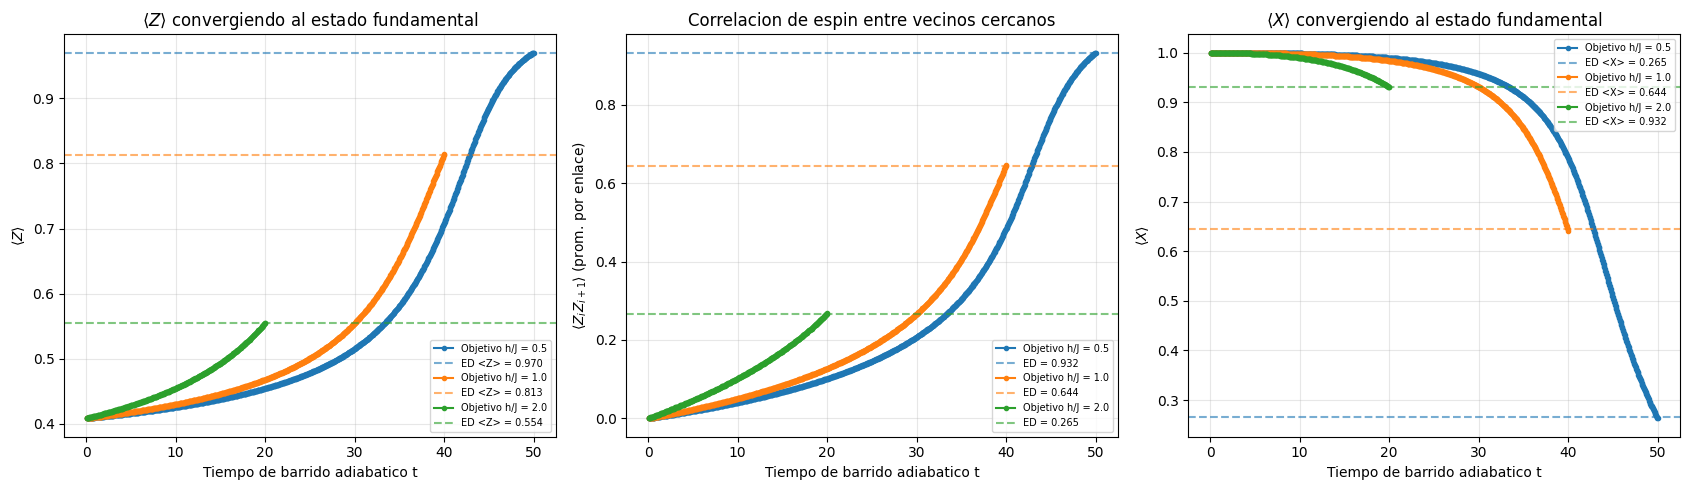

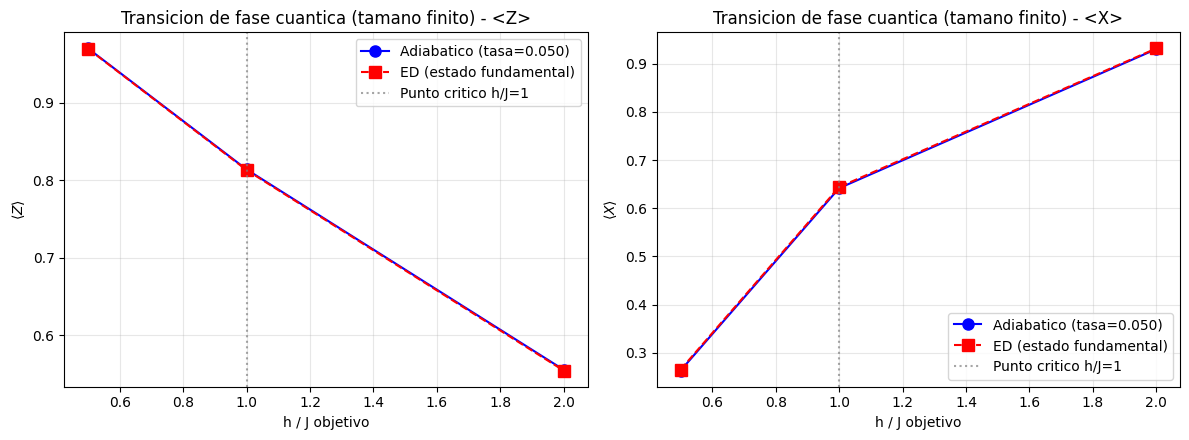


EVOLUCION TEMPORAL CON HAMILTONIANO FIJO DESDE ESTADO PRODUCTO (N=6)

Simulando h/J = 0.5 fijo desde el estado inicial |000000> ...
  Desviacion maxima en <Z>: 0.02%   Desviacion maxima en <Zi Zi+1>: 0.05%

Simulando h/J = 1.0 fijo desde el estado inicial |000000> ...
  Desviacion maxima en <Z>: 0.26%   Desviacion maxima en <Zi Zi+1>: 0.49%

Simulando h/J = 2.0 fijo desde el estado inicial |000000> ...
  Desviacion maxima en <Z>: 0.76%   Desviacion maxima en <Zi Zi+1>: 1.34%


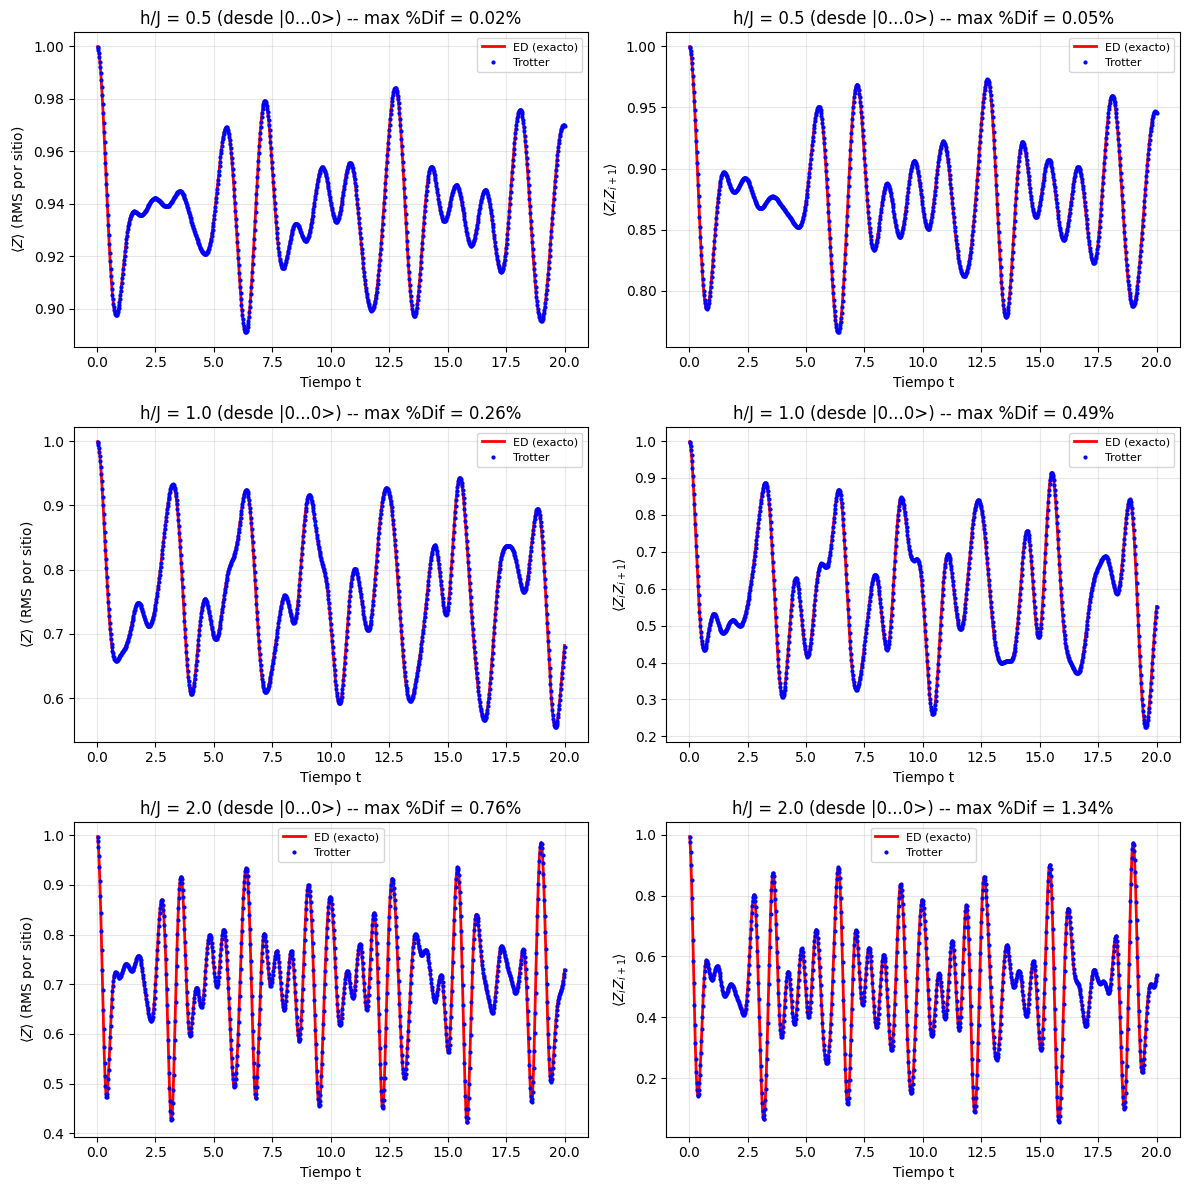


ESTUDIO DE ESCALAMIENTO EN N: quench de Trotter, h/J = 1.00, dt = 0.02, steps = 200
(referencia de ED solo se calcula para N <= 20)
 N   |  dim=2^N   |  tiempo (s)  |  max %Dif <Z>   |  max %Dif <ZZ> 
------------------------------------------------------------------------------
 4   |     16     |     0.25     |      0.041      |      0.082     
 6   |     64     |     0.21     |      0.060      |      0.105     
 8   |    256     |     0.30     |      0.025      |      0.042     
 10  |    1024    |     0.64     |      0.026      |      0.042     
 12  |    4096    |     1.23     |      0.028      |      0.042     
 14  |   16384    |     5.74     |      0.029      |      0.042     
 16  |   65536    |    16.76     |      0.028      |      0.042     
 18  |   262144   |    69.15     |      0.029      |      0.042     
 20  |  1048576   |    377.18    |      0.029      |      0.042     


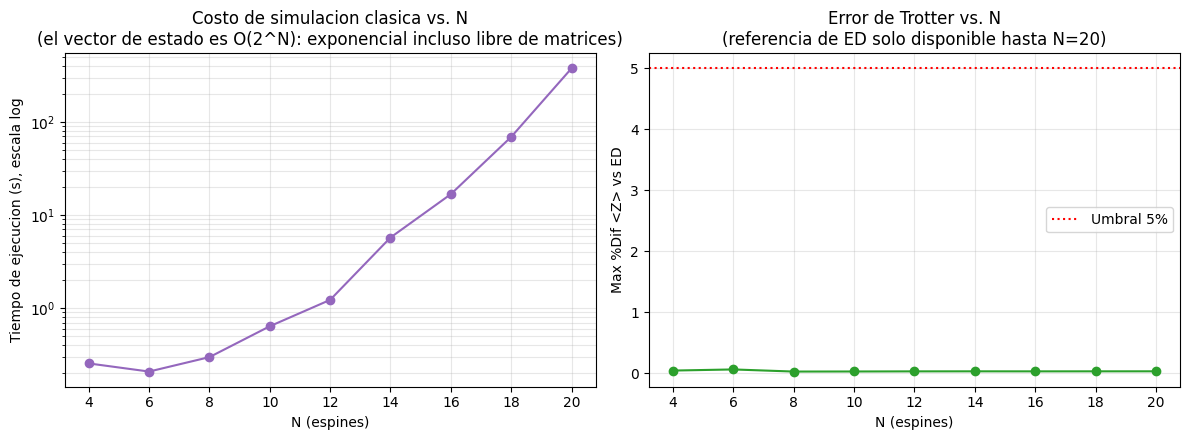


VQE: ENERGIA DEL ESTADO FUNDAMENTAL vs. DIAGONALIZACION EXACTA (ansatze en pytket)
 h/J   |    ED E/N    |  HW-eff E/N  |  %Dif HW   |   HVA E/N    |  %Dif HVA 
--------------------------------------------------------------------------------------------
 0.5   |  -1.064116   |  -1.056548   |   0.711  % |  -1.064116   |   0.000  %
 1.0   |  -1.287901   |  -1.233795   |   4.201  % |  -1.287901   |   0.000  %
 2.0   |  -2.128232   |  -2.097683   |   1.435  % |  -2.127987   |   0.011  %


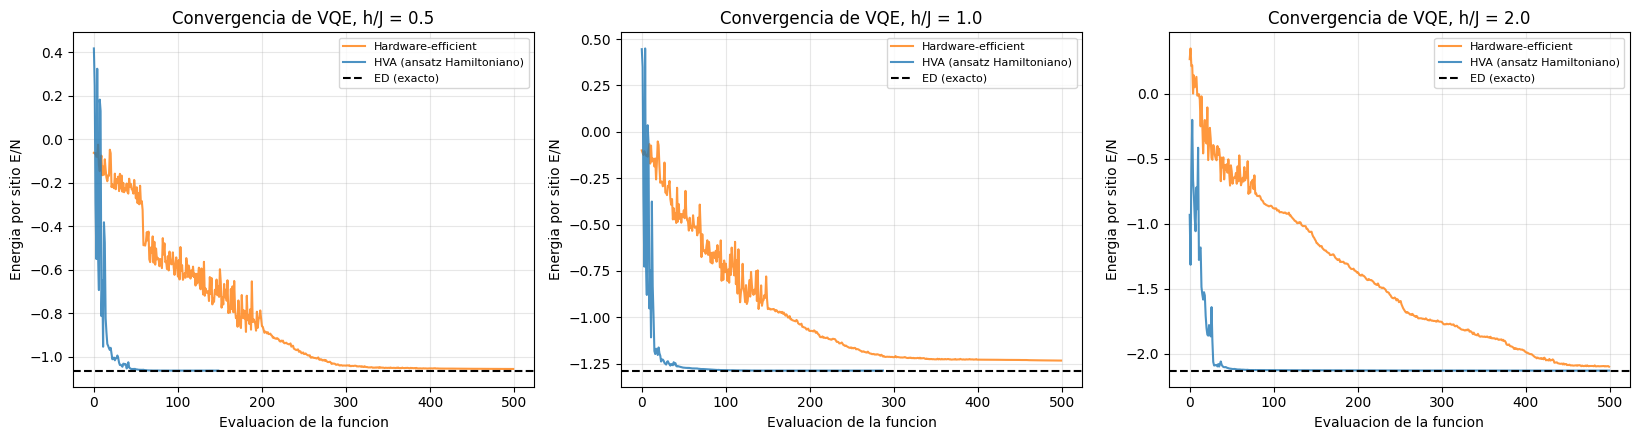


--- [Guppy] Corriendo circuito de quench localmente via el emulador (N=6, h=1.0, J=1.0, dt=0.02, pasos=30, shots=500) ---
[Guppy] Emulacion completada en 34.72s
[Guppy, 500 shots]      <Z> = 0.7259   <Zi Zi+1> = 0.4947
[Motor rapido, exacto]      <Z> = 0.6917   <Zi Zi+1> = 0.4382
(La diferencia esperada es ruido de muestreo ~ 1/sqrt(shots), no error de Trotter)

[Nexus] RUN_ON_NEXUS=False: no se envio nada a Quantinuum Nexus.
[Nexus] Para enviar un circuito real: cambiar RUN_ON_NEXUS=True (arriba)
[Nexus] y correr de nuevo, o llamar submit_to_nexus(circuito, ...) directamente
[Nexus] con cualquier Circuit de pytket construido en este archivo.

Linea base clasica completada (ED N=8 y N=6, barrido adiabatico,
dinamica de quench, escalamiento N=4-20, VQE, demo de Guppy)


In [ ]:
if __name__ == "__main__":
    # --- Parametros configurables por el usuario ---
    N_MAIN = 6                      # N usado en analisis a nivel de circuito
                                     # (barrido adiabatico, quench-vs-ED, VQE)
    N_BASELINE = 8                  # "Linea base clasica" del documento: ED en N=8
    N_SCALING_VALUES = [4, 6, 8, 10, 12, 14, 16, 18, 20]  # item 1: 4-20 espines
    ED_MAX_N = 20                   # referencia de ED (dispersa) factible hasta aqui
    J = 1.0
    h_values = [0.5, 1.0, 2.0]      # se puede ampliar el rango usando linspace,
                                    # pero estos son los puntos específicos pedidos en el reto

    print("=" * 60)
    print("Reto 3: SIMULACION TFIM (LOCAL, pytket + Guppy)")
    print("=" * 60)

    # ---- Linea base clasica: ED en N=8 (tal como pide el documento) ----
    ed_results_baseline = ed_baseline(N_BASELINE, h_values)

    # ---- ED en N=6 (usada para las comparaciones de circuito N=6, item 4) ----
    ed_results = ed_baseline(N_MAIN, h_values)

    # ---- Barrido adiabatico (preparacion de estado), N=6, cronograma escalado por tasa ----
    dt1 = 0.05
    rate_ref = 0.05
    trotter_data_1 = run_adiabatic_simulation(N_MAIN, J, h_values, dt1, rate_ref)
    print_comparison_table(ed_results, trotter_data_1, f"dt = {dt1:.3f}, tasa = {rate_ref:.3f}")

    fig, axes = plt.subplots(1, 3, figsize=(17, 5))
    ax = axes[0]
    for h in h_values:
        t = trotter_data_1[h]['time']
        ax.plot(t, trotter_data_1[h]['z_expect'], 'o-', markersize=3, label=f'Objetivo h/J = {h:.1f}')
        ed_z = next(r['mz_rms'] for r in ed_results if r['h'] == h)
        ax.axhline(y=ed_z, color=ax.lines[-1].get_color(), linestyle='--', alpha=0.6, label=f'ED <Z> = {ed_z:.3f}')
    ax.set_xlabel('Tiempo de barrido adiabatico t'); ax.set_ylabel(r'$\langle Z \rangle$')
    ax.set_title(r'$\langle Z \rangle$ convergiendo al estado fundamental'); ax.grid(True, alpha=0.3); ax.legend(loc='best', fontsize=7)

    ax = axes[1]
    for h in h_values:
        t = trotter_data_1[h]['time']
        ax.plot(t, trotter_data_1[h]['mzz'], 'o-', markersize=3, label=f'Objetivo h/J = {h:.1f}')
        ed_mzz = next(r['mzz'] for r in ed_results if r['h'] == h)
        ax.axhline(y=ed_mzz, color=ax.lines[-1].get_color(), linestyle='--', alpha=0.6, label=f'ED = {ed_mzz:.3f}')
    ax.set_xlabel('Tiempo de barrido adiabatico t'); ax.set_ylabel(r'$\langle Z_i Z_{i+1} \rangle$ (prom. por enlace)')
    ax.set_title('Correlacion de espin entre vecinos cercanos'); ax.grid(True, alpha=0.3); ax.legend(loc='best', fontsize=7)

    ax = axes[2]
    for h in h_values:
        t = trotter_data_1[h]['time']
        ax.plot(t, trotter_data_1[h]['x_expect'], 'o-', markersize=3, label=f'Objetivo h/J = {h:.1f}')
        ed_x = next(r['mx'] for r in ed_results if r['h'] == h)
        ax.axhline(y=ed_x, color=ax.lines[-1].get_color(), linestyle='--', alpha=0.6, label=f'ED <X> = {ed_x:.3f}')
    ax.set_xlabel('Tiempo de barrido adiabatico t'); ax.set_ylabel(r'$\langle X \rangle$')
    ax.set_title(r'$\langle X \rangle$ convergiendo al estado fundamental'); ax.grid(True, alpha=0.3); ax.legend(loc='best', fontsize=7)
    plt.tight_layout(); plt.show()

    # ---- Grafica de transicion de fase cuantica (estado final adiabatico vs ED) ----
    fig2, (ax2, ax3) = plt.subplots(1, 2, figsize=(12, 4.5))
    h_vals = h_values
    z_final = [trotter_data_1[h]['z_final'] for h in h_values]
    z_ed = [next(r['mz_rms'] for r in ed_results if r['h'] == h) for h in h_values]
    x_final = [trotter_data_1[h]['x_final'] for h in h_values]
    x_ed = [next(r['mx'] for r in ed_results if r['h'] == h) for h in h_values]

    ax2.plot(h_vals, z_final, 'bo-', markersize=8, label=f'Adiabatico (tasa={rate_ref:.3f})')
    ax2.plot(h_vals, z_ed, 'rs--', markersize=8, label='ED (estado fundamental)')
    ax2.axvline(x=1.0, color='gray', linestyle=':', alpha=0.7, label='Punto critico h/J=1')
    ax2.set_xlabel('h / J objetivo'); ax2.set_ylabel(r'$\langle Z \rangle$')
    ax2.set_title('Transicion de fase cuantica (tamano finito) - <Z>'); ax2.grid(True, alpha=0.3); ax2.legend()

    ax3.plot(h_vals, x_final, 'bo-', markersize=8, label=f'Adiabatico (tasa={rate_ref:.3f})')
    ax3.plot(h_vals, x_ed, 'rs--', markersize=8, label='ED (estado fundamental)')
    ax3.axvline(x=1.0, color='gray', linestyle=':', alpha=0.7, label='Punto critico h/J=1')
    ax3.set_xlabel('h / J objetivo'); ax3.set_ylabel(r'$\langle X \rangle$')
    ax3.set_title('Transicion de fase cuantica (tamano finito) - <X>'); ax3.grid(True, alpha=0.3); ax3.legend()
    plt.tight_layout(); plt.show()

    # ---- Evolucion temporal con Hamiltoniano fijo desde estado producto (N=6, vs ED) ----
    print("\n" + "=" * 60)
    print("EVOLUCION TEMPORAL CON HAMILTONIANO FIJO DESDE ESTADO PRODUCTO (N=6)")
    print("=" * 60)
    dt_fixed = 0.02          # verificado (reduciendo dt a la mitad) para mantener error << 5%
    steps_fixed = 1000       # tiempo total = 20.0
    initial_product_state = '0' * N_MAIN

    fig3, axes3 = plt.subplots(len(h_values), 2, figsize=(12, 4 * len(h_values)))
    for idx, h in enumerate(h_values):
        print(f"\nSimulando h/J = {h:.1f} fijo desde el estado inicial |{initial_product_state}> ...")
        times_ed, z_ed_time, mzz_ed_time, x_ed_time = ed_time_evolution_exact(
            N_MAIN, h, J, dt_fixed, steps_fixed, initial_product_state)
        times_trot, z_trot_time, mzz_trot_time, x_trot_time = run_trotter_quench(
            N_MAIN, h, J, dt_fixed, steps_fixed, initial_product_state, mirror=True)

        max_pct_z = np.max(np.abs(z_trot_time - z_ed_time)) / np.max(np.abs(z_ed_time)) * 100
        max_pct_mzz = np.max(np.abs(mzz_trot_time - mzz_ed_time)) / np.max(np.abs(mzz_ed_time)) * 100
        print(f"  Desviacion maxima en <Z>: {max_pct_z:.2f}%   Desviacion maxima en <Zi Zi+1>: {max_pct_mzz:.2f}%")

        ax1 = axes3[idx, 0] if len(h_values) > 1 else axes3[0]
        ax1.plot(times_ed, z_ed_time, 'r-', linewidth=2, label='ED (exacto)')
        ax1.plot(times_trot, z_trot_time, 'bo', markersize=2, label='Trotter')
        ax1.set_xlabel('Tiempo t'); ax1.set_ylabel(r'$\langle Z \rangle$ (RMS por sitio)')
        ax1.set_title(f'h/J = {h:.1f} (desde |0...0>) -- max %Dif = {max_pct_z:.2f}%')
        ax1.grid(True, alpha=0.3); ax1.legend(loc='best', fontsize=8)

        ax2b = axes3[idx, 1] if len(h_values) > 1 else axes3[1]
        ax2b.plot(times_ed, mzz_ed_time, 'r-', linewidth=2, label='ED (exacto)')
        ax2b.plot(times_trot, mzz_trot_time, 'bo', markersize=2, label='Trotter')
        ax2b.set_xlabel('Tiempo t'); ax2b.set_ylabel(r'$\langle Z_i Z_{i+1} \rangle$')
        ax2b.set_title(f'h/J = {h:.1f} (desde |0...0>) -- max %Dif = {max_pct_mzz:.2f}%')
        ax2b.grid(True, alpha=0.3); ax2b.legend(loc='best', fontsize=8)
    plt.tight_layout(); plt.show()

    # ---- ESTUDIO DE ESCALAMIENTO EN N (item 1): 4 a 20 espines, se degrada? ----
    scaling_results = trotter_scaling_study(N_SCALING_VALUES, h=1.0, J=1.0,
                                             dt=0.02, steps=200, ed_max_N=ED_MAX_N)

    fig5, (axr, axe) = plt.subplots(1, 2, figsize=(12, 4.5))
    Ns = sorted(scaling_results.keys())
    runtimes = [scaling_results[n]['runtime'] for n in Ns]
    axr.plot(Ns, runtimes, 'o-', color='tab:purple')
    axr.set_yscale('log')
    axr.set_xlabel('N (espines)'); axr.set_ylabel('Tiempo de ejecucion (s), escala log')
    axr.set_title('Costo de simulacion clasica vs. N\n(el vector de estado es O(2^N): exponencial incluso libre de matrices)')
    axr.grid(True, alpha=0.3, which='both')

    ed_Ns = [n for n in Ns if scaling_results[n]['max_pct_z'] is not None]
    ed_pct_z = [scaling_results[n]['max_pct_z'] for n in ed_Ns]
    axe.plot(ed_Ns, ed_pct_z, 'o-', color='tab:green')
    axe.axhline(y=5.0, color='red', linestyle=':', label='Umbral 5%')
    axe.set_xlabel('N (espines)'); axe.set_ylabel('Max %Dif <Z> vs ED')
    axe.set_title(f'Error de Trotter vs. N\n(referencia de ED solo disponible hasta N={ED_MAX_N})')
    axe.grid(True, alpha=0.3); axe.legend()
    plt.tight_layout(); plt.show()

    # ---- VQE: energia del estado fundamental vs ED (N=6) ----
    vqe_results = run_vqe_comparison(N_MAIN, J, h_values, hw_layers=3, hva_layers=4,
                                      n_restarts=6, maxiter=500, seed=42)

    fig4, axes4 = plt.subplots(1, len(h_values), figsize=(5.5 * len(h_values), 4.5))
    for idx, h in enumerate(h_values):
        ax = axes4[idx] if len(h_values) > 1 else axes4
        r = vqe_results[h]
        ax.plot(r['hw_history'], label='Hardware-efficient', color='tab:orange', alpha=0.8)
        ax.plot(r['hva_history'], label='HVA (ansatz Hamiltoniano)', color='tab:blue', alpha=0.8)
        ax.axhline(y=r['ed_energy'], color='black', linestyle='--', label='ED (exacto)')
        ax.set_xlabel('Evaluacion de la funcion')
        ax.set_ylabel('Energia por sitio E/N')
        ax.set_title(f'Convergencia de VQE, h/J = {h:.1f}')
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    # ---- [NUEVO] Demostracion en Guppy (circuito listo para Helios) ----
    demo_guppy_quench(N=N_MAIN, h=1.0, J=J, dt=0.02, steps=30, shots=500)

    # ---- [NUEVO] Envio a Nexus (apagado por defecto -- ver seccion 8) ----
    if not RUN_ON_NEXUS:
        print("\n[Nexus] RUN_ON_NEXUS=False: no se envio nada a Quantinuum Nexus.")
        print("[Nexus] Para enviar un circuito real: cambiar RUN_ON_NEXUS=True (arriba)")
        print("[Nexus] y correr de nuevo, o llamar submit_to_nexus(circuito, ...) directamente")
        print("[Nexus] con cualquier Circuit de pytket construido en este archivo.")

    print("\n" + "=" * 60)
    print("Linea base clasica completada (ED N=8 y N=6, barrido adiabatico,")
    print("dinamica de quench, escalamiento N=4-20, VQE, demo de Guppy)")
    print("=" * 60)